# Laboratorio 2 - Problema 4

# Transformaciones de intensidad

## Objetivo

Implementar las transformaciones de intensidad vistas en clase: negativa, lineal, logarítmica y exponencial, con el propósito de analizar cómo modifican la apariencia y el contraste de una imagen digital.

## Fundamento teórico

Las transformaciones de intensidad modifican el valor de cada píxel de una imagen mediante una función matemática.

Estas transformaciones permiten mejorar el contraste, resaltar detalles y adaptar la imagen para posteriores etapas del procesamiento digital.

En este laboratorio se implementan las siguientes transformaciones:

- Transformación negativa
- Transformación lineal
- Transformación logarítmica
- Transformación exponencial

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

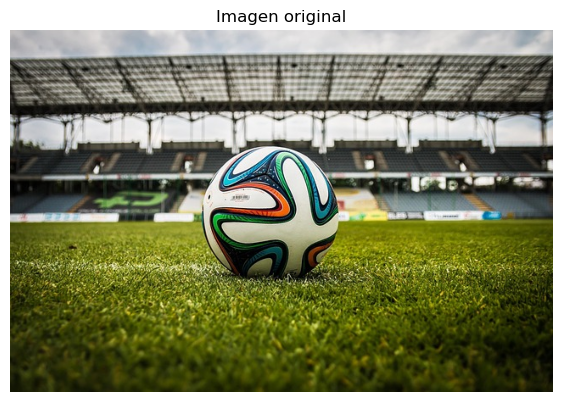

In [9]:
ruta = "../Imagenes lab/5.jpg"

imagen = cv2.imread(ruta)

if imagen is None:
    raise Exception("No se pudo cargar la imagen.")

# Convertir para visualizar correctamente
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,6))
plt.imshow(imagen_rgb)
plt.title("Imagen original")
plt.axis("off")
plt.show()

## Conversión a escala de grises

Aunque la imagen original se encuentra a color, las transformaciones de intensidad se aplicarán sobre su versión en escala de grises. Esto permite modificar únicamente el nivel de intensidad de cada píxel, facilitando el análisis del efecto producido por cada transformación.

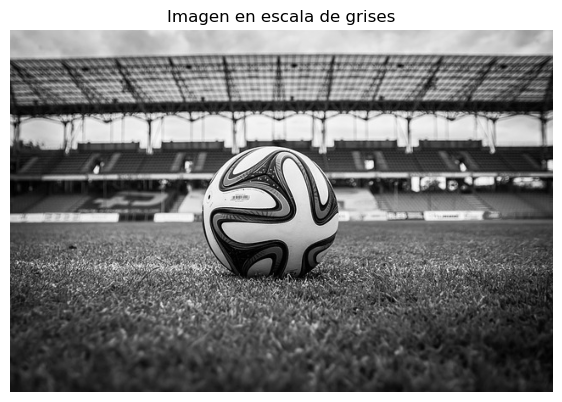

In [10]:
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(7,6))
plt.imshow(gris, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

## Implementación de las transformaciones

A continuación se implementa una función independiente para cada transformación solicitada.

In [3]:
def negativa(imagen):
    return 255 - imagen

In [4]:
def lineal(imagen, alpha=1.4, beta=25):
    """
    alpha = contraste
    beta = brillo
    """
    return cv2.convertScaleAbs(imagen, alpha=alpha, beta=beta)

In [5]:
def logaritmica(imagen):

    imagen = imagen.astype(np.float32)

    c = 255 / np.log(1 + np.max(imagen))

    log = c * np.log(1 + imagen)

    return np.uint8(log)

In [6]:
def exponencial(imagen, gamma=2):

    imagen = imagen / 255.0

    exp = np.power(imagen, gamma)

    exp = exp * 255

    return np.uint8(exp)

## Aplicación de las transformaciones

Se aplican las cuatro transformaciones implementadas anteriormente sobre la imagen en escala de grises.

In [7]:
neg = negativa(gris)

lin = lineal(gris)

log = logaritmica(gris)

exp = exponencial(gris)

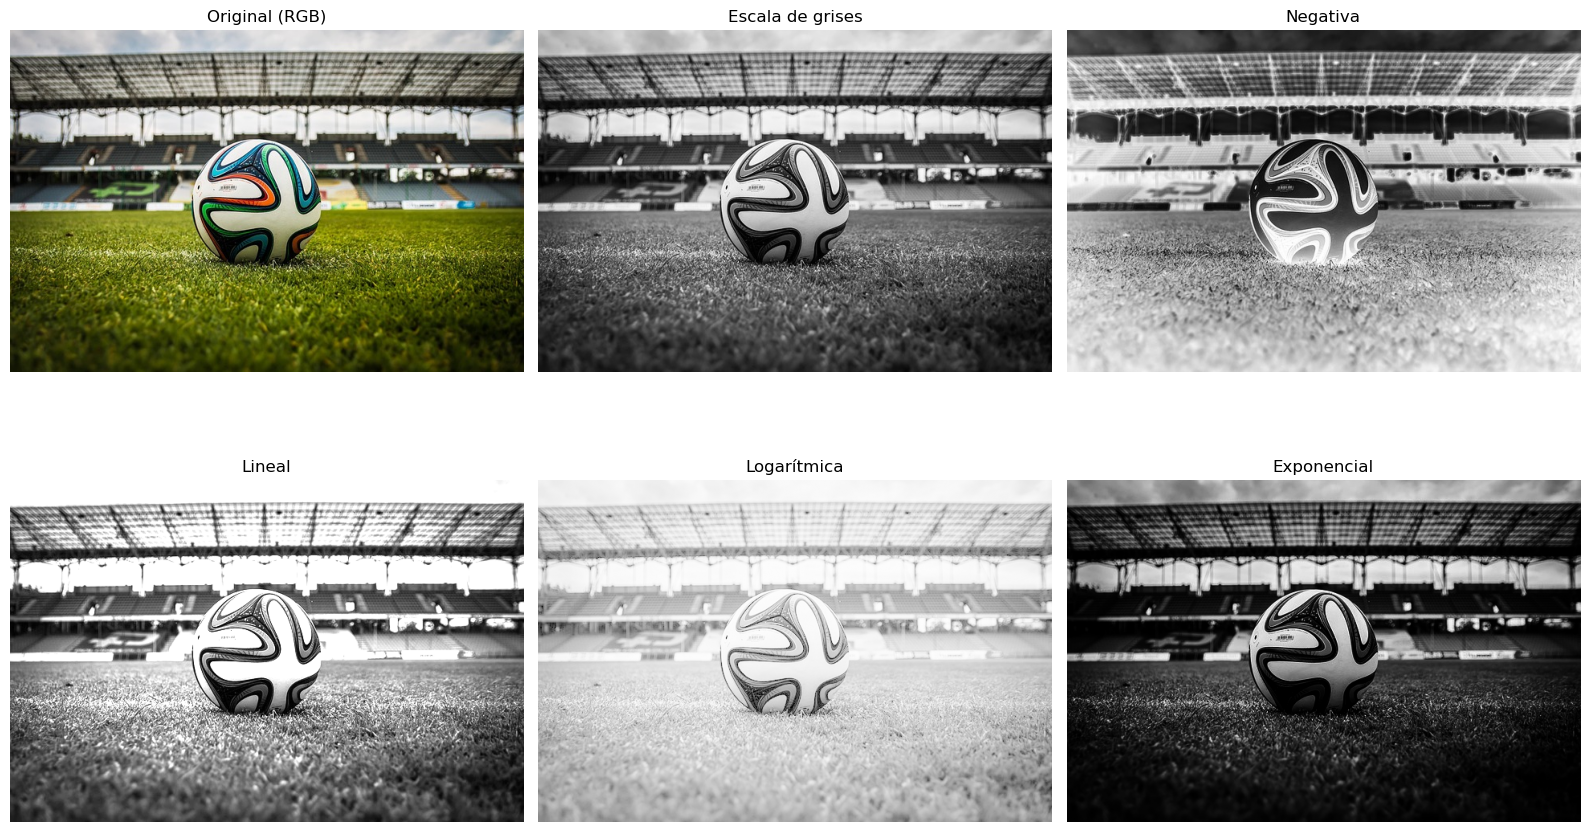

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(16,10))

imagenes = [
    imagen_rgb,
    gris,
    neg,
    lin,
    log,
    exp
]

titulos = [
    "Original (RGB)",
    "Escala de grises",
    "Negativa",
    "Lineal",
    "Logarítmica",
    "Exponencial"
]

for i, eje in enumerate(ax.ravel()):

    # La imagen original es RGB
    if i == 0:
        eje.imshow(imagenes[i])

    # Las demás son en escala de grises
    else:
        eje.imshow(imagenes[i], cmap="gray")

    eje.set_title(titulos[i], fontsize=12)
    eje.axis("off")

plt.tight_layout()
plt.show()

## Análisis de resultados

Cada transformación modifica la intensidad de los píxeles de manera distinta:

- La transformación **negativa** invierte los niveles de intensidad.
- La transformación **lineal** ajusta el brillo y el contraste mediante una relación lineal.
- La transformación **logarítmica** resalta los detalles presentes en regiones oscuras.
- La transformación **exponencial (gamma)** modifica la distribución de intensidades, permitiendo enfatizar regiones claras u oscuras según el valor del parámetro gamma.

## Conclusiones

Las transformaciones de intensidad constituyen herramientas fundamentales del procesamiento digital de imágenes.

Dependiendo de la aplicación, cada transformación permite mejorar características específicas de la imagen, facilitando tareas posteriores como segmentación, detección de bordes y reconocimiento de patrones.